# 🍛 Who Orders Where? Profiling Bangalore's Neighbourhoods Through Online Food Delivery Data

**Goal:** Use the location (latitude / longitude / pin code) attached to each customer record to divide Bangalore into geographic zones, then answer one question:

> *What kind of people live in each area, and how do they differ from one another?*

**Approach**

1. Clean the data and get a feel for the overall customer base
2. Look at where customers are located (pin codes, coordinates)
3. Group nearby locations into **geographic zones** with K-Means and give each zone a human-readable name
4. Profile every zone on demographics (age, gender, marital status, family size), socio-economics (occupation, income, education) and engagement (customer type, order status, feedback)
5. Test which differences are statistically meaningful
6. Summarise each zone as a resident **persona**

> ⚠️ Each row is one customer (survey-style record with a delivery location), so "residents" here means *food-delivery customers living in that area*, not the whole population.

## 1. Setup

In [1]:
import glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import chi2_contingency, kruskal

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

# Works both on Kaggle and locally

df = pd.read_csv("/kaggle/input/datasets/srisyra02/online-food-ordering-dataset/online food delivery dataset.csv")
print(df.shape)
df.head()

(388, 14)


,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Output,Feedback,Unnamed: 13
0,20,Female,Single,Student,No Income,Post Graduate,4,Frequent,12.9766,77.5993,560001,Yes,Positive,Yes
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,Regular,12.9770,77.5773,560009,Yes,Positive,Yes
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,Regular,12.9551,77.6593,560017,Yes,Negative,Yes
3,22,Female,Single,Student,No Income,Graduate,6,Frequent,12.9473,77.5616,560019,Yes,Positive,Yes
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,Frequent,12.9850,77.5533,560010,Yes,Positive,Yes


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         388 non-null    int64  
 1   Gender                      388 non-null    object 
 2   Marital Status              388 non-null    object 
 3   Occupation                  388 non-null    object 
 4   Monthly Income              388 non-null    object 
 5   Educational Qualifications  388 non-null    object 
 6   Family size                 388 non-null    int64  
 7   Customer Type               388 non-null    object 
 8   latitude                    388 non-null    float64
 9   longitude                   388 non-null    float64
 10  Pin code                    388 non-null    int64  
 11  Output                      388 non-null    object 
 12  Feedback                    388 non-null    object 
 13  Unnamed: 13                 388 non

In [6]:
print(df.duplicated().sum())

103


In [7]:
df[df.duplicated()]

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Output,Feedback,Unnamed: 13
43,22,Female,Single,Student,No Income,Post Graduate,5,Frequent,12.9850,77.5533,560010,Yes,Positive,Yes
48,23,Female,Single,Student,No Income,Graduate,3,Regular,12.9820,77.6256,560008,Yes,Negative,Yes
49,22,Female,Single,Student,10001 to 25000,Post Graduate,5,Frequent,12.9850,77.5533,560010,Yes,Positive,Yes
52,24,Male,Single,Student,No Income,Post Graduate,3,Regular,12.9770,77.5773,560009,Yes,Positive,Yes
60,23,Male,Single,Student,No Income,Post Graduate,5,Frequent,12.8988,77.5764,560078,Yes,Positive,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
382,24,Female,Single,Student,No Income,Post Graduate,3,Regular,12.9828,77.6131,560042,Yes,Positive,Yes
383,23,Female,Single,Student,No Income,Post Graduate,2,Regular,12.9766,77.5993,560001,Yes,Positive,Yes
384,23,Female,Single,Student,No Income,Post Graduate,4,Frequent,12.9854,77.7081,560048,Yes,Positive,Yes
385,22,Female,Single,Student,No Income,Post Graduate,5,Frequent,12.9850,77.5533,560010,Yes,Positive,Yes


In [8]:
df1 = df.drop_duplicates()


In [9]:
df1.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
355    False
363    False
369    False
374    False
386    False
Length: 285, dtype: bool

In [10]:
df1["Unnamed: 13"]

0      Yes
1      Yes
2      Yes
3      Yes
4      Yes
      ... 
355     No
363    Yes
369    Yes
374    Yes
386    Yes
Name: Unnamed: 13, Length: 285, dtype: object

In [3]:
df = df.drop(columns=['Unnamed: 13'])

In [5]:
X_geo = df[['latitude', 'longitude']]

In [6]:
import plotly.express as px

In [7]:
fig = px.scatter_mapbox(
    X_geo,
    lat="latitude",
    lon="longitude",
    zoom=10,
    mapbox_style="open-street-map",
)
fig.show()


In [8]:
results = []

for k in range(2, 10):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_geo)

    results.append({
        'k': k,
        'inertia': model.inertia_,
        'silhouette': silhouette_score(
            X_geo,
            labels
        )
    })



In [9]:
results_df = pd.DataFrame(results)

print(results_df)

   k   inertia  silhouette
0  2  1.081207    0.375733
1  3  0.731924    0.381341
2  4  0.582199    0.385055
3  5  0.454080    0.414907
4  6  0.360060    0.422436
5  7  0.298948    0.440066
6  8  0.259498    0.400785
7  9  0.232738    0.402626


In [10]:
kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=20
)

df['zone'] = kmeans.fit_predict(X_geo) + 1

In [11]:
df['zone']

0      2
1      2
2      1
3      3
4      2
      ..
383    2
384    5
385    2
386    2
387    3
Name: zone, Length: 388, dtype: int32

In [12]:
centers = kmeans.cluster_centers_
centers

array([[12.98385946, 77.64043378],
       [12.98338188, 77.57022391],
       [12.91826438, 77.5768274 ],
       [13.05150698, 77.55991628],
       [12.98507778, 77.73842222],
       [12.92063571, 77.65005952]])

In [13]:

centers_df = pd.DataFrame(
    centers,
    columns=['latitude', 'longitude']
)

centers_df['zone'] = range(1, 7)

print("\nCluster centers:")
print(centers_df)


Cluster centers:
    latitude  longitude  zone
0  12.983859  77.640434     1
1  12.983382  77.570224     2
2  12.918264  77.576827     3
3  13.051507  77.559916     4
4  12.985078  77.738422     5
5  12.920636  77.650060     6


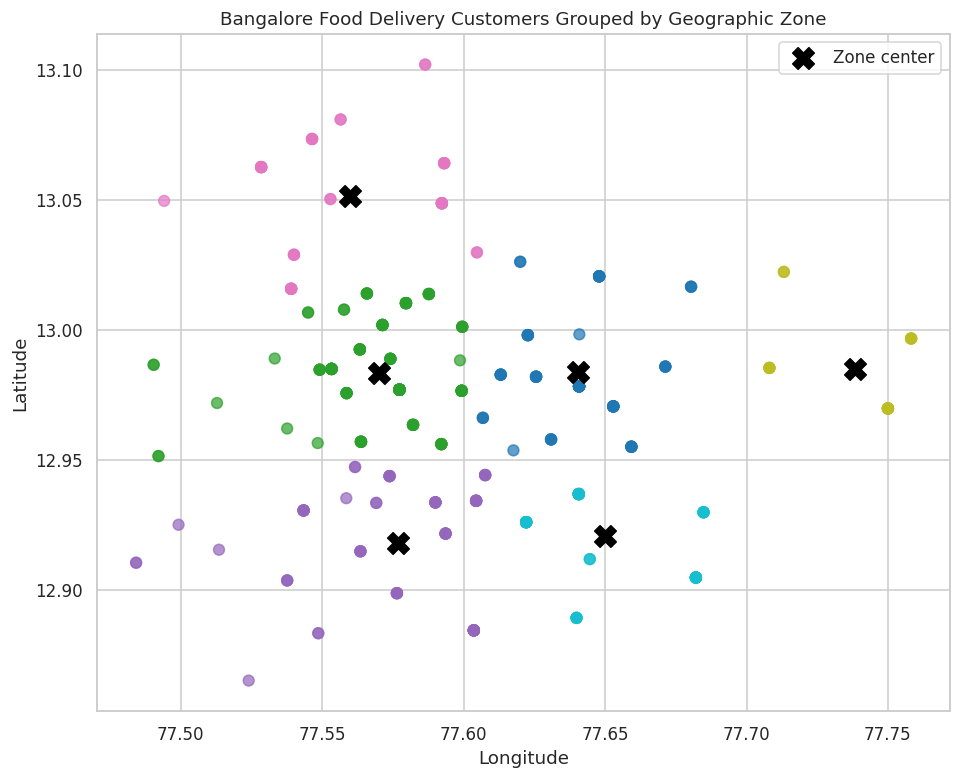

In [14]:

plt.figure(figsize=(10, 8))

plt.scatter(
    df['longitude'],
    df['latitude'],
    c=df['zone'],
    cmap='tab10',
    s=50,
    alpha=0.7
)

plt.scatter(
    centers[:, 1],
    centers[:, 0],
    marker='X',
    c='black',
    s=200,
    label='Zone center'
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "Bangalore Food Delivery Customers "
    "Grouped by Geographic Zone"
)

plt.legend()
plt.show()


In [22]:
import plotly.graph_objects as go

fig = px.scatter_mapbox(
    df,
    lat=df["latitude"],  # replace with your latitude column name
    lon=df["longitude"],  # replace with your longitude column name
    color=df["zone"],  # colors points based on your zones
    hover_name="zone",
   
    zoom=10,
    height=600,
)
fig.add_trace(
    go.Scattermapbox(
        lat=centers_df['latitude'],
        lon=centers_df['longitude'],
        mode='markers',
        marker=go.scattermapbox.Marker(
            size=54,
            color='red',
            symbol='X' # Cross marker
        ),
        name='Zone Center'
    )
)


# Use an open-source map style
fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r": 0, "t": 0, "l": 0, "b": 0})

# Show the map
fig.show()

In [23]:
profile = df.groupby('zone').agg(
    customers=('zone', 'size'),
    avg_age=('Age', 'mean'),
    avg_family_size=('Family size', 'mean'),
    order_yes_pct=('Output', lambda x: (x == 'Yes').mean() * 100),
    positive_feedback_pct=(
        'Feedback',
        lambda x: (x == 'Positive').mean() * 100
    )
)

profile = profile.round(2)

print(profile)

      customers  avg_age  avg_family_size  order_yes_pct  \
zone                                                       
1            74    25.42             3.57          81.08   
2           138    24.25             2.97          76.09   
3            73    24.30             3.59          84.93   
4            43    24.49             3.21          62.79   
5            18    24.56             3.33          66.67   
6            42    25.24             3.31          83.33   

      positive_feedback_pct  
zone                         
1                     75.68  
2                     80.43  
3                     90.41  
4                     69.77  
5                     94.44  
6                     88.10  


In [24]:
profile.head()

,customers,avg_age,avg_family_size,order_yes_pct,positive_feedback_pct
zone,,,,,
1,74,25.42,3.57,81.08,75.68
2,138,24.25,2.97,76.09,80.43
3,73,24.30,3.59,84.93,90.41
4,43,24.49,3.21,62.79,69.77
5,18,24.56,3.33,66.67,94.44


In [25]:
occupation_profile = pd.crosstab(
    df['zone'],
    df['Occupation'],
    normalize='index'
) * 100

occupation_profile = occupation_profile.round(1)

print(occupation_profile)

Occupation  Employee  House wife  Self Employeed  Student
zone                                                     
1               35.1         4.1            23.0     37.8
2               23.2         2.9            12.3     61.6
3               28.8         1.4            15.1     54.8
4               14.0         2.3            14.0     69.8
5               55.6         0.0            11.1     33.3
6               54.8         0.0             2.4     42.9


In [28]:
df['Monthly Income'].unique()

array(['No Income', 'Below Rs.10000', 'More than 50000', '10001 to 25000',
       '25001 to 50000'], dtype=object)

In [29]:
Income_profile = pd.crosstab(
    df['zone'],
    df['Monthly Income']
) 

Income_profile = Income_profile.round(1)

print(Income_profile)

Monthly Income  10001 to 25000  25001 to 50000  Below Rs.10000  \
zone                                                             
1                           13              18               7   
2                           10              20              13   
3                           13              11               3   
4                            1               7               1   
5                            4               4               1   
6                            4               9               0   

Monthly Income  More than 50000  No Income  
zone                                        
1                            10         26  
2                            20         75  
3                            12         34  
4                             6         28  
5                             3          6  
6                            11         18  


In [30]:
Income_profile.head()

Monthly Income,10001 to 25000,25001 to 50000,Below Rs.10000,More than 50000,No Income
zone,,,,,
1,13,18,7,10,26
2,10,20,13,20,75
3,13,11,3,12,34
4,1,7,1,6,28
5,4,4,1,3,6


## 2. Data cleaning

In [ ]:
df = df_raw.copy()

# The unnamed last column is an exact duplicate of `Output`
print("Unnamed column identical to Output:", (df["Output"] == df.iloc[:, -1]).all())
df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")])

# Strip stray whitespace (e.g. 'Negative ')
for c in df.select_dtypes(exclude="number").columns:
    df[c] = df[c].astype(str).str.strip()

df = df.rename(columns={"Self Employeed": "Self Employed"})
df["Occupation"] = df["Occupation"].replace({"Self Employeed": "Self Employed", "House wife": "Housewife"})

# Ordered categories make every chart read left-to-right sensibly
INCOME_ORDER = ["No Income", "Below Rs.10000", "10001 to 25000", "25001 to 50000", "More than 50000"]
EDU_ORDER    = ["Uneducated", "School", "Graduate", "Post Graduate", "Ph.D"]
OCC_ORDER    = ["Student", "Employee", "Self Employed", "Housewife"]
MAR_ORDER    = ["Single", "Married", "Prefer not to say"]
CUST_ORDER   = ["New", "Regular", "Frequent"]

df["Monthly Income"] = pd.Categorical(df["Monthly Income"], INCOME_ORDER, ordered=True)
df["Educational Qualifications"] = pd.Categorical(df["Educational Qualifications"], EDU_ORDER, ordered=True)
df["Occupation"] = pd.Categorical(df["Occupation"], OCC_ORDER)
df["Marital Status"] = pd.Categorical(df["Marital Status"], MAR_ORDER)
df["Customer Type"] = pd.Categorical(df["Customer Type"], CUST_ORDER, ordered=True)

# Numeric income proxy = midpoint of each bracket (top bracket set conservatively to 60k)
income_mid = {"No Income": 0, "Below Rs.10000": 5_000, "10001 to 25000": 17_500,
              "25001 to 50000": 37_500, "More than 50000": 60_000}
df["income_est"] = df["Monthly Income"].astype(str).map(income_mid)

print(df.isna().sum().sum(), "missing values")
df.info()

## 3. The customer base at a glance

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
sns.histplot(df["Age"], bins=range(17, 35), ax=axes[0, 0], color="#4C72B0"); axes[0, 0].set_title("Age")
sns.countplot(x="Family size", data=df, ax=axes[0, 1], color="#55A868"); axes[0, 1].set_title("Family size")
for ax, col in zip(axes.flat[2:], ["Gender", "Marital Status", "Occupation",
                                   "Monthly Income", "Educational Qualifications", "Customer Type"]):
    vc = df[col].value_counts(sort=False)
    ax.barh(vc.index.astype(str), vc.values, color=sns.color_palette("Set2", len(vc)))
    ax.set_title(col); ax.invert_yaxis()
plt.suptitle("Overall customer profile (n = %d)" % len(df), fontsize=15, y=1.01)
plt.tight_layout(); plt.show()

print(f"Median age: {df.Age.median():.0f} | Students: {(df.Occupation=='Student').mean():.0%} | "
      f"Single: {(df['Marital Status']=='Single').mean():.0%} | Graduate+: "
      f"{df['Educational Qualifications'].isin(['Graduate','Post Graduate','Ph.D']).mean():.0%}")

The customer base is **young (18–33), highly educated, and dominated by students and singles** — about half report no income. Any area-level differences we find are therefore variations *within* a young urban population, which makes them more interesting, not less.

## 4. Where are the customers?

In [ ]:
pin_counts = df["Pin code"].value_counts()
print(f"{df['Pin code'].nunique()} unique pin codes; median {pin_counts.median():.0f} customers per pin code")
print(f"Pin codes with fewer than 5 customers: {(pin_counts < 5).sum()} ({(pin_counts < 5).mean():.0%})")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
hb = axes[0].hexbin(df.longitude, df.latitude, gridsize=25, cmap="YlOrRd", mincnt=1)
plt.colorbar(hb, ax=axes[0], label="customers")
axes[0].set_title("Customer density across Bangalore"); axes[0].set_xlabel("longitude"); axes[0].set_ylabel("latitude")
axes[0].set_aspect("equal")

pin_counts.head(15).sort_values().plot.barh(ax=axes[1], color="#C44E52")
axes[1].set_title("Top 15 pin codes by customers"); axes[1].set_xlabel("customers")
plt.tight_layout(); plt.show()

With ~77 pin codes and most of them holding only a handful of customers, **pin codes are too granular** for reliable profiling. Instead we cluster the coordinates into a small number of geographic zones that each contain enough people to describe.

## 5. Building geographic zones

In [ ]:
X = df[["latitude", "longitude"]].values
ks = range(2, 10)
inertia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit(X)
    inertia.append(km.inertia_); sil.append(silhouette_score(X, km.labels_))
    
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(ks, inertia, "o-", color="#4C72B0"); ax1.set_ylabel("inertia", color="#4C72B0"); ax1.set_xlabel("k")
ax2 = ax1.twinx(); ax2.plot(ks, sil, "s--", color="#C44E52"); ax2.set_ylabel("silhouette", color="#C44E52")
ax1.axvline(5, color="grey", ls=":"); plt.title("Choosing the number of zones"); plt.show()

Silhouette keeps rising up to k = 7, but beyond k = 5 the new clusters are small (fewer than 20 customers), which makes their profiles noisy. **k = 5** is a good compromise: clearly separated zones, and every zone keeps 30+ customers.

Each zone is then named automatically by its **distance and compass bearing** from the city centre (MG Road, ~12.9716 N, 77.5946 E): *Inner* if the centroid is within 7 km, *Outer* otherwise.

In [ ]:
K = 5
km = KMeans(n_clusters=K, n_init=20, random_state=RANDOM_STATE).fit(X)
df["zone_id"] = km.labels_

CENTER = (12.9716, 77.5946)
DIRS = ["North", "Northeast", "East", "Southeast", "South", "Southwest", "West", "Northwest"]

def describe_centroid(lat, lon):
    dy = (lat - CENTER[0]) * 111.0
    dx = (lon - CENTER[1]) * 111.0 * np.cos(np.radians(CENTER[0]))
    dist = np.hypot(dx, dy)
    bearing = np.degrees(np.arctan2(dx, dy)) % 360
    direction = DIRS[int(((bearing + 22.5) % 360) // 45)]
    ring = "Inner" if dist < 7 else "Outer"
    return f"{ring} {direction}", dist, bearing

zone_info = []
for zid, (lat, lon) in enumerate(km.cluster_centers_):
    name, dist, bearing = describe_centroid(lat, lon)
    zone_info.append({"zone_id": zid, "zone": name, "centroid_lat": lat, "centroid_lon": lon,
                      "km_from_center": round(dist, 1), "bearing_deg": round(bearing)})
zone_info = pd.DataFrame(zone_info)
zone_info["zone"] = zone_info["zone"].where(~zone_info["zone"].duplicated(keep=False),
                                            zone_info["zone"] + " " + zone_info["zone_id"].astype(str))
df = df.merge(zone_info[["zone_id", "zone"]], on="zone_id")

ZONE_ORDER = zone_info.sort_values("km_from_center")["zone"].tolist()
df["zone"] = pd.Categorical(df["zone"], ZONE_ORDER, ordered=True)
PALETTE = dict(zip(ZONE_ORDER, sns.color_palette("tab10", K)))

zone_info = zone_info.merge(df.groupby("zone", observed=True).agg(customers=("Age", "size"),
                                                   pin_codes=("Pin code", "nunique")), on="zone")
zone_info.set_index("zone").loc[ZONE_ORDER]

In [ ]:
fig, ax = plt.subplots(figsize=(9, 9))
for z in ZONE_ORDER:
    d = df[df.zone == z]
    ax.scatter(d.longitude, d.latitude, s=40, alpha=.7, color=PALETTE[z], label=f"{z} (n={len(d)})", edgecolor="white", lw=.5)
for _, r in zone_info.iterrows():
    ax.scatter(r.centroid_lon, r.centroid_lat, marker="X", s=250, color=PALETTE[r.zone], edgecolor="black")
    ax.annotate(r.zone, (r.centroid_lon, r.centroid_lat), xytext=(8, 8), textcoords="offset points",
                fontsize=11, weight="bold", bbox=dict(boxstyle="round", fc="white", alpha=.8))
ax.scatter(*CENTER[::-1], marker="*", s=400, color="gold", edgecolor="black", zorder=5, label="City centre (MG Road)")
ax.set_aspect("equal"); ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.set_title("Five geographic zones of Bangalore food-delivery customers", fontsize=14)
ax.legend(loc="upper right", fontsize=9, framealpha=.9); plt.show()

### Interactive map
Hover over a point to see who lives there; use the layer control (top right) to switch base maps and toggle zones. All base maps are key-free.

> **If the map does not appear:** on Kaggle, run the cell (folium is pre-installed; turn on *Settings → Internet* only if the auto-install below is needed). In a local Jupyter, choose *Trust Notebook* or simply re-run this cell — untrusted notebooks hide JavaScript outputs.

In [ ]:
try:
    import folium
except ImportError:
    %pip install -q folium
    import folium

# Base maps that need no API key. (Some providers, e.g. CARTO / Stadia, reject requests
# coming from notebook iframes and draw an "API key required" tile instead.)
fmap = folium.Map(location=CENTER, zoom_start=11, tiles=None)
ESRI = "https://server.arcgisonline.com/ArcGIS/rest/services"
folium.TileLayer(f"{ESRI}/Canvas/World_Light_Gray_Base/MapServer/tile/{{z}}/{{y}}/{{x}}",
                 attr="Tiles &copy; Esri &mdash; Esri, DeLorme, NAVTEQ", name="Esri Light Gray",
                 max_zoom=16).add_to(fmap)
folium.TileLayer(f"{ESRI}/World_Street_Map/MapServer/tile/{{z}}/{{y}}/{{x}}",
                 attr="Tiles &copy; Esri", name="Esri Streets").add_to(fmap)
folium.TileLayer("OpenStreetMap", name="OpenStreetMap").add_to(fmap)
hex_colors = {z: "#%02x%02x%02x" % tuple(int(c * 255) for c in PALETTE[z]) for z in ZONE_ORDER}

for z in ZONE_ORDER:
    layer = folium.FeatureGroup(name=f"{z} (n={(df.zone == z).sum()})")
    for _, r in df[df.zone == z].iterrows():
        folium.CircleMarker(
            [r.latitude, r.longitude], radius=6, color=hex_colors[z], weight=1,
            fill=True, fill_color=hex_colors[z], fill_opacity=.7,
            tooltip=(f"<b>{z}</b> | Pin {r['Pin code']}<br>{r.Age} y, {r.Gender}, {r['Marital Status']}<br>"
                     f"{r.Occupation} · {r['Monthly Income']}<br>Family size: {r['Family size']} · "
                     f"Feedback: {r.Feedback}")).add_to(layer)
    c = zone_info.loc[zone_info.zone == z].iloc[0]
    folium.Marker([c.centroid_lat, c.centroid_lon], tooltip=f"<b>{z}</b> centroid",
                  icon=folium.DivIcon(html=f'<div style="font-size:12px;font-weight:bold;color:{hex_colors[z]};'
                                           f'background:white;padding:2px 4px;border-radius:4px;'
                                           f'border:1px solid {hex_colors[z]};white-space:nowrap">{z}</div>')).add_to(layer)
    layer.add_to(fmap)

folium.Marker(CENTER, tooltip="City centre (MG Road)", icon=folium.Icon(color="orange", icon="star")).add_to(fmap)
folium.LayerControl(collapsed=False).add_to(fmap)
fmap.save("bangalore_zones_map.html")   # also saved as a standalone file in the output folder
fmap

## 6. Profiling each zone

### 6.1 Zone fingerprint heatmap
Key indicators per zone. Colours show how far a zone deviates from the city-wide value (z-score across zones); numbers are the actual values.

In [ ]:
g = df.groupby("zone", observed=True)
profile = pd.DataFrame({
    "Customers":            g.size(),
    "Avg age":              g["Age"].mean(),
    "Avg family size":      g["Family size"].mean(),
    "Est. income (Rs)":     g["income_est"].mean(),
    "% Male":               g["Gender"].apply(lambda s: (s == "Male").mean() * 100),
    "% Single":             g["Marital Status"].apply(lambda s: (s == "Single").mean() * 100),
    "% Married":            g["Marital Status"].apply(lambda s: (s == "Married").mean() * 100),
    "% Student":            g["Occupation"].apply(lambda s: (s == "Student").mean() * 100),
    "% Employee":           g["Occupation"].apply(lambda s: (s == "Employee").mean() * 100),
    "% Self employed":      g["Occupation"].apply(lambda s: (s == "Self Employed").mean() * 100),
    "% No income":          g["Monthly Income"].apply(lambda s: (s == "No Income").mean() * 100),
    "% Income > 50k":       g["Monthly Income"].apply(lambda s: (s == "More than 50000").mean() * 100),
    "% Post-grad / PhD":    g["Educational Qualifications"].apply(lambda s: s.isin(["Post Graduate", "Ph.D"]).mean() * 100),
    "% Frequent customers": g["Customer Type"].apply(lambda s: (s == "Frequent").mean() * 100),
    "% Output = Yes":       g["Output"].apply(lambda s: (s == "Yes").mean() * 100),
    "% Positive feedback":  g["Feedback"].apply(lambda s: (s == "Positive").mean() * 100),
}).loc[ZONE_ORDER]

z = (profile - profile.mean()) / profile.std()

fig, ax = plt.subplots(figsize=(15, 5.5))
annot = profile.apply(lambda col: col.map(lambda v: f"{v:,.0f}" if col.name in ("Customers", "Est. income (Rs)") else f"{v:.1f}"))
sns.heatmap(z, annot=annot, fmt="",
            cmap="RdBu_r", center=0, vmin=-1.8, vmax=1.8, linewidths=.5, cbar_kws={"label": "z-score vs other zones"}, ax=ax)
ax.set_title("Zone fingerprints: who lives where?", fontsize=14); ax.set_ylabel("")
plt.xticks(rotation=40, ha="right"); plt.tight_layout(); plt.show()

### 6.2 Socio-economic composition

In [ ]:
def stacked(ax, col, order, cmap):
    ct = pd.crosstab(df["zone"], df[col], normalize="index").reindex(index=ZONE_ORDER, columns=order).fillna(0) * 100
    ct.plot.barh(stacked=True, ax=ax, color=sns.color_palette(cmap, len(order)), width=.8, edgecolor="white")
    for i, row in enumerate(ct.values):
        left = 0
        for v in row:
            if v >= 8: ax.text(left + v / 2, i, f"{v:.0f}%", ha="center", va="center", fontsize=8.5)
            left += v
    ax.set_title(col); ax.set_xlabel("% of zone"); ax.set_ylabel(""); ax.invert_yaxis()
    ax.legend(bbox_to_anchor=(1.0, 1), loc="upper left", fontsize=8, frameon=False)

fig, axes = plt.subplots(3, 1, figsize=(12, 13))
stacked(axes[0], "Occupation", OCC_ORDER, "Set2")
stacked(axes[1], "Monthly Income", INCOME_ORDER, "YlGn")
stacked(axes[2], "Educational Qualifications", EDU_ORDER, "PuBu")
plt.tight_layout(); plt.show()

### 6.3 Household & demographics

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
sns.boxplot(data=df, x="zone", y="Age", order=ZONE_ORDER, palette=PALETTE, ax=axes[0, 0])
sns.pointplot(data=df, x="zone", y="Age", order=ZONE_ORDER, color="black", markers="D", ax=axes[0, 0], errorbar=None)
axes[0, 0].set_title("Age (◆ = mean)")

fam = pd.crosstab(df["zone"], pd.cut(df["Family size"], [0, 2, 4, 6], labels=["1–2", "3–4", "5–6"]),
                  normalize="index").loc[ZONE_ORDER] * 100
fam.plot.bar(ax=axes[0, 1], color=sns.color_palette("Oranges", 3), edgecolor="white")
axes[0, 1].set_title("Household size (% of zone)"); axes[0, 1].set_xlabel(""); axes[0, 1].tick_params(axis="x", rotation=0)

stacked(axes[1, 0], "Marital Status", MAR_ORDER, "Pastel1")
gen = pd.crosstab(df["zone"], df["Gender"], normalize="index").loc[ZONE_ORDER] * 100
gen.plot.barh(stacked=True, ax=axes[1, 1], color=["#DD8452", "#4C72B0"], edgecolor="white")
axes[1, 1].axvline(50, color="black", ls=":"); axes[1, 1].invert_yaxis()
axes[1, 1].set_title("Gender"); axes[1, 1].set_ylabel(""); axes[1, 1].set_xlabel("% of zone")
for ax in axes[0]: ax.set_xlabel("")
plt.tight_layout(); plt.show()

### 6.4 Ordering behaviour and satisfaction

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
stacked(axes[0], "Customer Type", CUST_ORDER, "Blues")
for ax, col, pos, color in [(axes[1], "Output", "Yes", "#55A868"), (axes[2], "Feedback", "Positive", "#8172B2")]:
    rate = df.groupby("zone", observed=True)[col].apply(lambda s: (s == pos).mean() * 100).loc[ZONE_ORDER]
    n = df.groupby("zone", observed=True).size().loc[ZONE_ORDER]
    se = np.sqrt(rate / 100 * (1 - rate / 100) / n) * 100 * 1.96
    ax.barh(ZONE_ORDER, rate, xerr=se, color=[PALETTE[z] for z in ZONE_ORDER], capsize=4)
    overall = (df[col] == pos).mean() * 100
    ax.axvline(overall, color="black", ls="--", label=f"city-wide {overall:.0f}%")
    for i, v in enumerate(rate): ax.text(3, i, f"{v:.0f}%", va="center", color="white", weight="bold")
    ax.set_title(f"% {col} = {pos}  (95% CI)"); ax.set_xlim(0, 105); ax.invert_yaxis(); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

## 7. Are the differences real? Statistical tests

Chi-square tests for categorical variables and Kruskal–Wallis for numeric ones. **Cramér's V** / **ε²** give the effect size (0 = no association). With several tests and small cells, treat p-values between 0.01 and 0.05 as *suggestive* rather than conclusive.

In [ ]:
rows = []
for col in ["Gender", "Marital Status", "Occupation", "Monthly Income", "Educational Qualifications",
            "Customer Type", "Output", "Feedback"]:
    ct = pd.crosstab(df["zone"], df[col])
    chi2, p, dof, exp = chi2_contingency(ct)
    v = np.sqrt(chi2 / (len(df) * (min(ct.shape) - 1)))
    rows.append({"variable": col, "test": "Chi-square", "p_value": p, "effect size": v,
                 "cells with expected < 5": f"{(exp < 5).mean():.0%}"})
for col in ["Age", "Family size", "income_est"]:
    H, p = kruskal(*[d[col] for _, d in df.groupby("zone", observed=True)])
    eps2 = (H - K + 1) / (len(df) - K)
    rows.append({"variable": col, "test": "Kruskal-Wallis", "p_value": p, "effect size": eps2,
                 "cells with expected < 5": "–"})
tests = pd.DataFrame(rows).sort_values("p_value")
tests["significant (α=0.05)"] = np.where(tests.p_value < 0.05, "✅", "–")
tests.style.format({"p_value": "{:.4f}", "effect size": "{:.3f}"}).background_gradient(subset=["p_value"], cmap="Greens_r")

## 8. Zooming in: pin-code level

For pin codes with at least 5 customers, a bubble map shows the share of students (colour) and the number of customers (size) — revealing *student pockets* vs *working-professional pockets* inside the zones.

In [ ]:
MIN_N = 5
pin = df.groupby("Pin code").agg(
    customers=("Age", "size"), lat=("latitude", "mean"), lon=("longitude", "mean"),
    zone=("zone", lambda s: s.mode()[0]), avg_age=("Age", "mean"),
    pct_student=("Occupation", lambda s: (s == "Student").mean() * 100),
    est_income=("income_est", "mean"),
    pct_positive=("Feedback", lambda s: (s == "Positive").mean() * 100))
pin_big = pin[pin.customers >= MIN_N]

fig, axes = plt.subplots(1, 2, figsize=(17, 7.5))
for ax, col, cmap, label in [(axes[0], "pct_student", "coolwarm", "% students"),
                             (axes[1], "est_income", "viridis", "est. avg monthly income (Rs)")]:
    ax.scatter(df.longitude, df.latitude, s=6, color="lightgrey")
    sc = ax.scatter(pin_big.lon, pin_big.lat, s=pin_big.customers * 25, c=pin_big[col], cmap=cmap,
                    edgecolor="black", alpha=.85)
    for code_, r in pin_big.iterrows():
        ax.annotate(str(code_)[-3:], (r.lon, r.lat), ha="center", va="center", fontsize=7, weight="bold")
    plt.colorbar(sc, ax=ax, label=label, shrink=.8)
    ax.set_aspect("equal"); ax.set_title(f"Pin codes with ≥{MIN_N} customers — {label}\n(label = last 3 digits, size = customers)")
plt.tight_layout(); plt.show()

pin_big.drop(columns=["lat", "lon"]).sort_values("customers", ascending=False).round(1).style.background_gradient(
    subset=["pct_student", "est_income"], cmap="RdYlGn")

### 8.1 Sensitivity check: one dominant pin code
One pin code holds far more customers than any other. Does it drive its zone's profile on its own?

In [ ]:
top_pin = pin_counts.index[0]
home_zone = df.loc[df["Pin code"] == top_pin, "zone"].mode()[0]
zdf = df[df.zone == home_zone]
def quick(d):
    return pd.Series({"customers": len(d), "avg age": d.Age.mean(),
                      "% student": (d.Occupation == "Student").mean() * 100,
                      "% single": (d["Marital Status"] == "Single").mean() * 100,
                      "% no income": (d["Monthly Income"] == "No Income").mean() * 100,
                      "avg family size": d["Family size"].mean()})
pd.DataFrame({f"Pin {top_pin} only": quick(zdf[zdf["Pin code"] == top_pin]),
              f"{home_zone} (all)": quick(zdf),
              f"{home_zone} without {top_pin}": quick(zdf[zdf["Pin code"] != top_pin]),
              "City-wide": quick(df)}).round(1)

## 9. Resident personas

A radar chart compares zones on six normalised dimensions, followed by an automatically generated persona for each zone (features that deviate most from the city-wide average).

In [ ]:
radar_cols = ["Avg age", "Avg family size", "Est. income (Rs)", "% Employee", "% Post-grad / PhD", "% Frequent customers"]
R = profile[radar_cols]
R = (R - R.min()) / (R.max() - R.min())
angles = np.linspace(0, 2 * np.pi, len(radar_cols), endpoint=False).tolist(); angles += angles[:1]

radar_labels = ["Age", "Family size", "Income", "Employees", "Post-grad", "Frequent"]
fig, axes = plt.subplots(1, K, figsize=(4.6 * K, 5), subplot_kw=dict(polar=True))
plt.subplots_adjust(wspace=.45)
for ax, zname in zip(axes, ZONE_ORDER):
    vals = R.loc[zname].tolist() + [R.loc[zname].iloc[0]]
    ax.plot(angles, vals, color=PALETTE[zname], lw=2); ax.fill(angles, vals, color=PALETTE[zname], alpha=.3)
    ax.set_theta_offset(np.pi / 2); ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(radar_labels, fontsize=9)
    ax.set_yticklabels([]); ax.set_ylim(0, 1); ax.set_title(zname, weight="bold", color=PALETTE[zname], pad=14)
plt.suptitle("Relative zone profiles (min–max scaled across zones: centre = lowest zone, edge = highest)", y=1.04, fontsize=14); plt.show()

In [ ]:
city = pd.Series({
    "Avg age": df.Age.mean(), "Avg family size": df["Family size"].mean(), "Est. income (Rs)": df.income_est.mean(),
    "% Student": (df.Occupation == "Student").mean() * 100, "% Employee": (df.Occupation == "Employee").mean() * 100,
    "% Married": (df["Marital Status"] == "Married").mean() * 100,
    "% Post-grad / PhD": df["Educational Qualifications"].isin(["Post Graduate", "Ph.D"]).mean() * 100,
    "% Frequent customers": (df["Customer Type"] == "Frequent").mean() * 100,
    "% Positive feedback": (df.Feedback == "Positive").mean() * 100,
    "% Output = Yes": (df.Output == "Yes").mean() * 100})

rel = (profile[city.index] - city) / profile[city.index].std()
for zname in ZONE_ORDER:
    top = rel.loc[zname].abs().sort_values(ascending=False).head(4).index
    bullets = [f"{c}: {profile.loc[zname, c]:,.1f} (city {city[c]:,.1f}) {'▲' if rel.loc[zname, c] > 0 else '▼'}" for c in top]
    print(f"■ {zname}  —  {profile.loc[zname, 'Customers']:.0f} customers")
    for b in bullets: print("    ", b)
    print()

## 10. Key findings

### Zone personas

| Zone | Persona | What sets it apart |
|---|---|---|
| **Inner Northwest** (139 customers, ~3 km NW of centre) | 🎓 **The student belt** | Youngest zone (24.2 y), 63% students, 76% single, smallest households (3.0), highest post-grad share (59%), lowest estimated income — and the *lowest* share of frequent customers (28%). |
| **Inner East** (85, ~5 km E) | 🏠 **Settled families & entrepreneurs** | Oldest zone (25.5 y), most married (39%), largest households (3.6), most self-employed (20%), and the lowest post-grad share (37%). |
| **Inner South** (96, ~6 km S) | ⚖️ **The balanced, happy middle** | Close to the city average on demographics, the most male-skewed zone (65%), and the best engagement: 84% Output = Yes and 88% positive feedback. |
| **Outer North** (36, ~10 km N) | 🚲 **Student outskirts with a service gap** | 64% students, 61% with no income, only 17% salaried employees — and clearly the weakest engagement (56% Output = Yes, 67% positive feedback). |
| **Outer East** (32, ~13 km E) | 💼 **Young professionals** | 56% salaried employees, 28% earning > Rs 50k (2× any other zone), highest estimated income, almost no self-employed, and 97% positive feedback. Lies in the direction of the city's eastern IT corridor. |

### Cross-cutting insights

1. **Occupation is the strongest demographic divider between areas** (lowest p-value). Where people live in this sample is mostly a story of *students vs. working professionals*.
2. **Satisfaction varies by place more than any demographic does.** Output and Feedback show the largest effect sizes (Cramér's V ≈ 0.18). The Outer North stands out negatively, which points to a possible delivery-coverage or restaurant-density issue at the city edge rather than a customer-type effect — its customers are *frequent* orderers yet the least satisfied.
3. **The two outer zones are opposites.** Distance from the centre alone does not predict who lives there: the Outer North is student-heavy and low-income, the Outer East is professional and high-income. *Direction* matters more than *distance*.
4. **One campus-like pin code shapes a whole zone.** Pin 560009 alone holds 36 customers, 97% of them single students with no income. Without it, the Inner Northwest looks almost exactly like the city average — the "student belt" is really a **student hotspot**.
5. **Gender and customer type do not differ meaningfully between zones**, so they are poor signals for area-based targeting.

### What this means in practice
- **Inner Northwest / pin 560009:** budget combos, student discounts, late-night delivery.
- **Inner East:** family-size meals and bulk orders.
- **Outer East:** premium, office-lunch and weekday-dinner offers.
- **Outer North:** investigate delivery times and restaurant coverage first — the demand (frequent users) is there, the experience is not.

## 11. Limitations & next steps

**Limitations**
- **Small sample** (388 customers). Zone profiles rest on 30–140 people each; pin-code profiles on even fewer. Findings are indicative, not definitive.
- **Survey population ≠ residents.** The sample skews young and student-heavy (likely collected around colleges), so it describes *delivery-app customers*, not the full population of each neighbourhood.
- **Income is bracketed.** The numeric income estimate uses bracket midpoints; the top bracket is open-ended.
- **Zone boundaries are data-driven.** K-Means on raw coordinates gives compact zones, but they do not follow administrative borders. Results can shift slightly with a different k.
- **Multiple testing.** Eleven tests were run. With a strict Bonferroni correction (α ≈ 0.0045) none would pass, although Occupation, Output and Feedback come close (p ≈ 0.006–0.01). The zone differences are consistent and interpretable, but should be read as strong hints rather than proof.


*If you found this notebook useful, an upvote is appreciated! 🙌*

Thank you!